In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import warnings
import io
import os

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

### 2. Load Dataset
Please upload your airline dataset CSV file when prompted below.

In [3]:
from google.colab import files

uploaded = files.upload()

# Automatically detect the uploaded CSV file
if not uploaded:
    print("No file uploaded. Please upload a CSV file to proceed.")
else:
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))

    print(f"File '{file_name}' loaded successfully.")
    print("\nShape:", df.shape)
    print("\nData Types:")
    print(df.dtypes)
    display(df.head())
    display(df.tail())

Saving flights.csv to flights.csv
File 'flights.csv' loaded successfully.

Shape: (15000, 12)

Data Types:
index               int64
airline            object
date_of_journey    object
Source             object
destination        object
route              object
dep_time           object
Arrival_time       object
Duration           object
Total_stops        object
Additional_info    object
Price               int64
dtype: object


,index,airline,date_of_journey,Source,destination,route,dep_time,Arrival_time,Duration,Total_stops,Additional_info,Price
0,1,AirAsia India,2024-02-25,Guwahati,Indore,GUW-NAG-MUM-RAI-IND,01:39,14:15,3h 15min,3 stops,Red-eye flight,14170
1,2,TruJet,2021-03-01,Nagpur,Pune,NAG-PUN,06:48,03:21,1h 0min,non-stop,1 Long layover,10295
2,3,Star Air,2024-04-11,Ahmedabad,Varanasi,AHM-PUN-BAN-VAR,08:54,15:50,14h 30min,2 stops,In-flight meal not included,9165
3,4,SpiceJet,2019-03-13,Patna,Indore,PAT-LUC-GOA-BHU-IND,18:09,08:23,7h 15min,3 stops,No info,9944
4,5,SpiceJet,2023-06-22,Raipur,Mumbai,RAI-GOA-MUM,15:05,05:52,15h 30min,1 stop,1 Long layover,9474


,index,airline,date_of_journey,Source,destination,route,dep_time,Arrival_time,Duration,Total_stops,Additional_info,Price
14995,14996,SpiceJet,2023-09-26,Indore,Guwahati,IND-KOL-GUW,18:58,17:21,7h 30min,1 stop,In-flight meal not included,11660
14996,14997,Air India,2025-10-04,Lucknow,Varanasi,LUC-BAN-VAR,00:01,13:08,10h 0min,1 stop,Limited seats,9268
14997,14998,Alliance Air,2019-02-19,Bhubaneswar,Raipur,BHU-MUM-RAI,02:04,21:41,6h 45min,1 stop,Extra baggage allowed,5516
14998,14999,Alliance Air,2025-02-16,Cochin,Lucknow,COC-KOL-PUN-LUC,16:20,06:10,14h 30min,2 stops,Business class available,12085
14999,15000,Air India,2020-06-03,Goa,Patna,GOA-VAR-AHM-NAG-PAT,21:55,08:05,11h 45min,3 stops,Business class available,12724


### 3. Data Understanding

In [4]:
def understand_data(dataframe):
    print("--- Dataset Dimensions ---")
    print(f"Rows: {dataframe.shape[0]}, Columns: {dataframe.shape[1]}")

    print("\n--- Column Names ---")
    print(dataframe.columns.tolist())

    print("\n--- Memory Usage ---")
    print(dataframe.memory_usage(deep=True).sum() / 1024**2, "MB")

    print("\n--- Missing Values ---")
    print(dataframe.isnull().sum()[dataframe.isnull().sum() > 0])

    print("\n--- Duplicate Rows ---")
    print(dataframe.duplicated().sum())

understand_data(df)

--- Dataset Dimensions ---
Rows: 15000, Columns: 12

--- Column Names ---
['index', 'airline', 'date_of_journey', 'Source', 'destination', 'route', 'dep_time', 'Arrival_time', 'Duration', 'Total_stops', 'Additional_info', 'Price']

--- Memory Usage ---
8.469135284423828 MB

--- Missing Values ---
Series([], dtype: int64)

--- Duplicate Rows ---
0


### 4. Data Cleaning
We will handle missing values, duplicates, and perform feature engineering to extract time-based components and delay categories.

In [5]:
import pandas as pd

# 1. Remove duplicates
df.drop_duplicates(inplace=True)

# 2. Convert Date columns - adapted for 'date_of_journey'
date_col = 'date_of_journey' if 'date_of_journey' in df.columns else next((col for col in df.columns if 'DATE' in col.upper()), None)

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df.dropna(subset=[date_col], inplace=True)
    df['Year'] = df[date_col].dt.year
    df['Month'] = df[date_col].dt.month
    df['Day'] = df[date_col].dt.day
    df['Weekday'] = df[date_col].dt.day_name()

    # Season Mapping
    df['Season'] = df['Month'].map({12:'Winter', 1:'Winter', 2:'Winter',
                                    3:'Spring', 4:'Spring', 5:'Spring',
                                    6:'Summer', 7:'Summer', 8:'Summer',
                                    9:'Autumn', 10:'Autumn', 11:'Autumn'})

# 3. Create Price/Delay Categories (Adapting to available numerical columns if ARR_DELAY is missing)
# Since your current CSV has 'Price', we'll treat that as a primary metric for now,
# but keep the structure for Delay if those columns exist in a different version.
def categorize_value(val):
    if val <= df['Price'].median(): return 'Budget/Low'
    else: return 'Premium/High'

if 'Price' in df.columns:
    df['Price_Category'] = df['Price'].apply(categorize_value)

# Filling numerical NAs with 0
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

print("Cleaning complete. Processed", len(df), "rows.")

Cleaning complete. Processed 15000 rows.


### 5. Statistical Summary
In this section, we calculate central tendency, dispersion, and distribution shapes for numerical features.

In [6]:
def get_statistical_summary(dataframe):
    # Select only numeric columns
    numeric_df = dataframe.select_dtypes(include=[np.number])

    # Basic describe
    summary = numeric_df.describe().T

    # Additional metrics
    summary['median'] = numeric_df.median()
    summary['mode'] = numeric_df.mode().iloc[0]
    summary['variance'] = numeric_df.var()
    summary['skewness'] = numeric_df.skew()
    summary['kurtosis'] = numeric_df.kurtosis()

    return summary

stats_summary = get_statistical_summary(df)
display(stats_summary)

# Outlier Summary using IQR
def detect_outliers(dataframe):
    outlier_counts = {}
    numeric_cols = dataframe.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = dataframe[(dataframe[col] < (Q1 - 1.5 * IQR)) | (dataframe[col] > (Q3 + 1.5 * IQR))]
        outlier_counts[col] = len(outliers)
    return pd.Series(outlier_counts)

print("\n--- Outlier Summary (Count per Column) ---")
print(detect_outliers(df))

,count,mean,std,min,25%,50%,75%,max,median,mode,variance,skewness,kurtosis
index,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.5,11250.25,15000.0,7500.5,1.0,1.875125e+07,0.000000,-1.200000
Price,15000.0,9355.349000,3290.049097,2502.0,6852.00,9354.0,11755.00,17900.0,9354.0,7445.0,1.082442e+07,0.078792,-0.690800
Year,15000.0,2021.988800,1.986220,2019.0,2020.00,2022.0,2024.00,2025.0,2022.0,2022.0,3.945071e+00,0.017838,-1.231581
Month,15000.0,6.515933,3.449793,1.0,3.00,7.0,9.00,12.0,7.0,9.0,1.190107e+01,-0.009069,-1.209858
Day,15000.0,14.396133,8.087585,1.0,7.00,14.0,21.00,28.0,14.0,16.0,6.540904e+01,0.015645,-1.204646



--- Outlier Summary (Count per Column) ---
index    0
Price    0
Year     0
Month    0
Day      0
dtype: int64


### 6. Univariate Analysis
Visualizing the distribution of key variables using Histograms, KDEs, Boxplots, and Count plots.

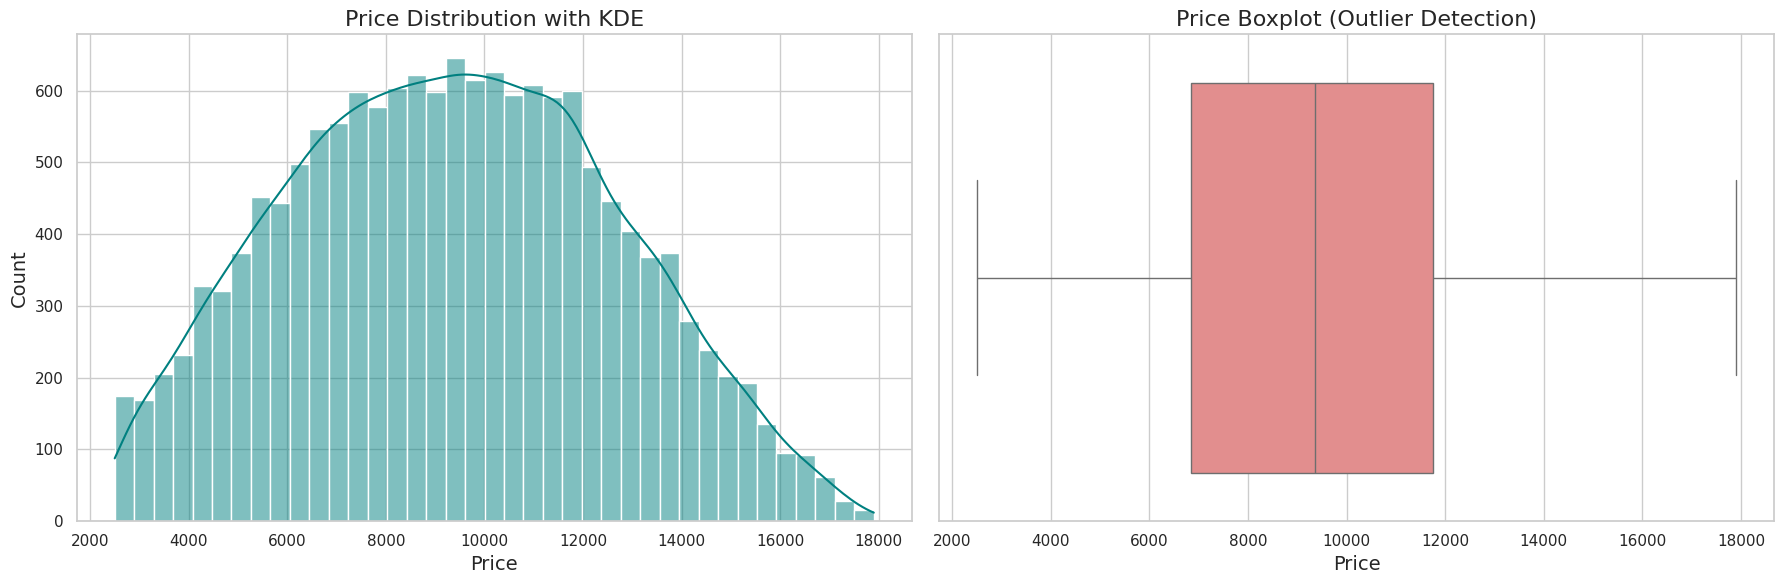

Interpretation: The price distribution shows the typical cost range for flights. Outliers in the boxplot indicate premium or last-minute bookings.


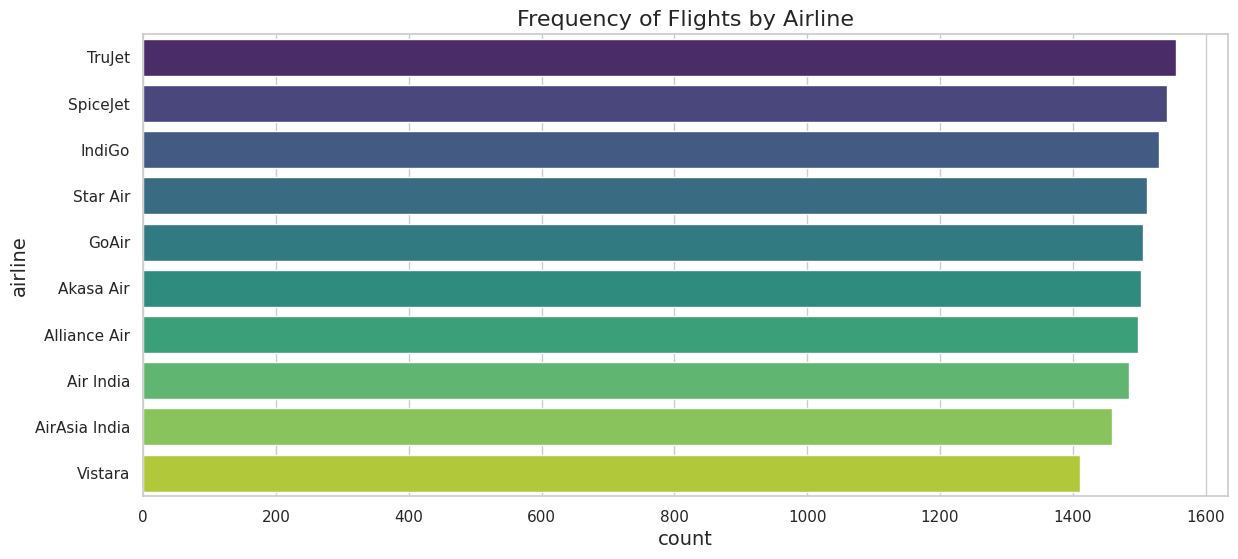

Interpretation: This chart identifies the dominant airlines in the dataset based on flight frequency.


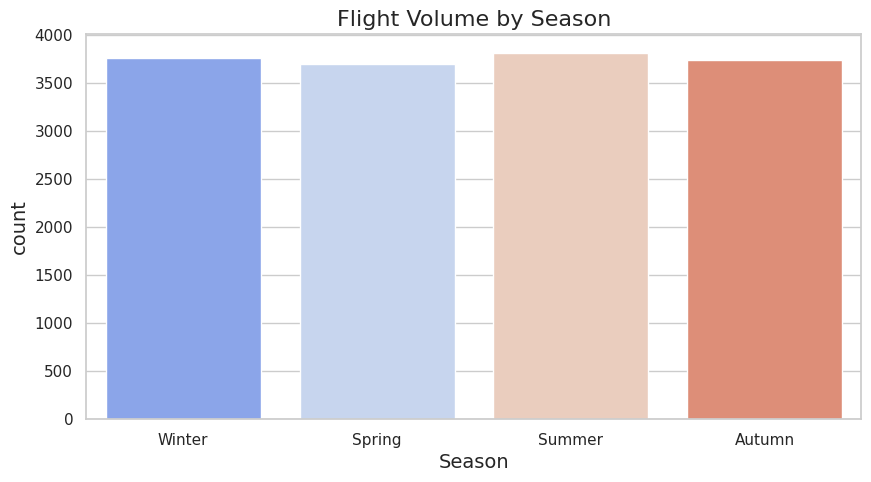

In [7]:
# 1. Distribution of Price
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['Price'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Price Distribution with KDE')

sns.boxplot(x=df['Price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Price Boxplot (Outlier Detection)')

plt.tight_layout()
plt.show()

print("Interpretation: The price distribution shows the typical cost range for flights. Outliers in the boxplot indicate premium or last-minute bookings.")

# 2. Airline Count Plot
plt.figure(figsize=(14, 6))
sns.countplot(data=df, y='airline', order=df['airline'].value_counts().index, palette='viridis')
plt.title('Frequency of Flights by Airline')
plt.show()

print("Interpretation: This chart identifies the dominant airlines in the dataset based on flight frequency.")

# 3. Seasonal Count Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Season', palette='coolwarm')
plt.title('Flight Volume by Season')
plt.show()

### 7. Bivariate Analysis
Analyzing the relationships between flight price and categorical features like Airline and Source.

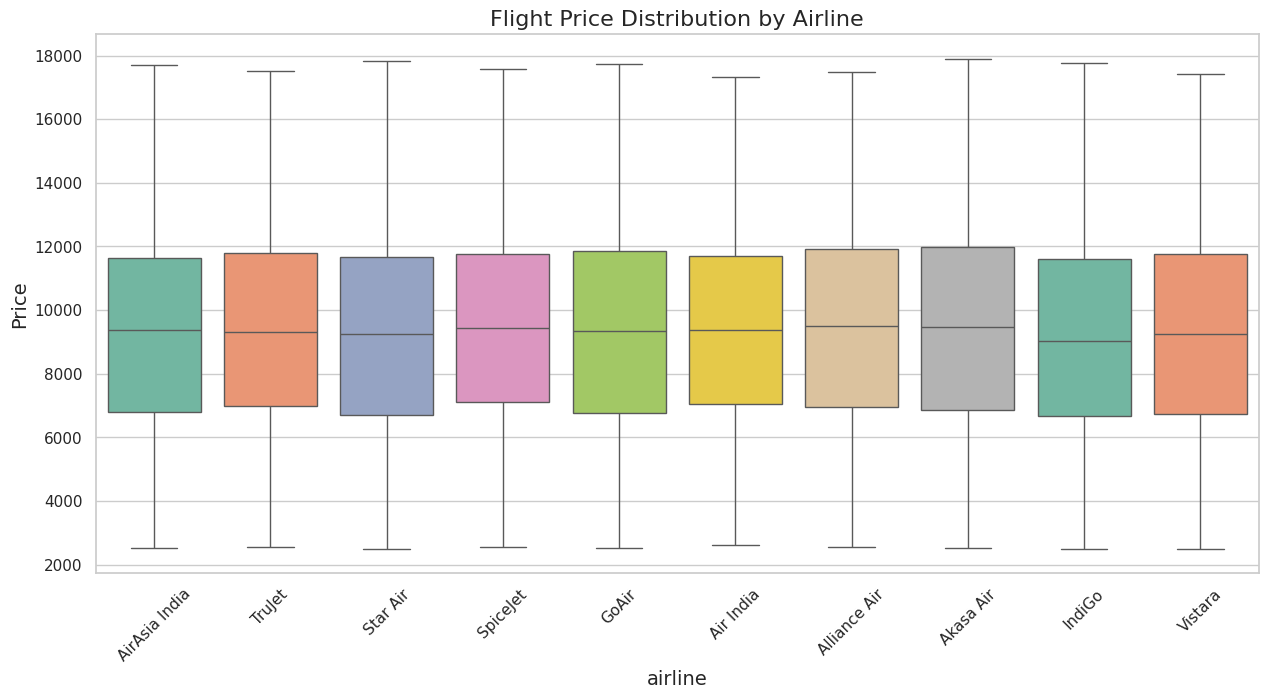

Interpretation: This plot highlights the price variance across different carriers, identifying budget vs. premium airlines.


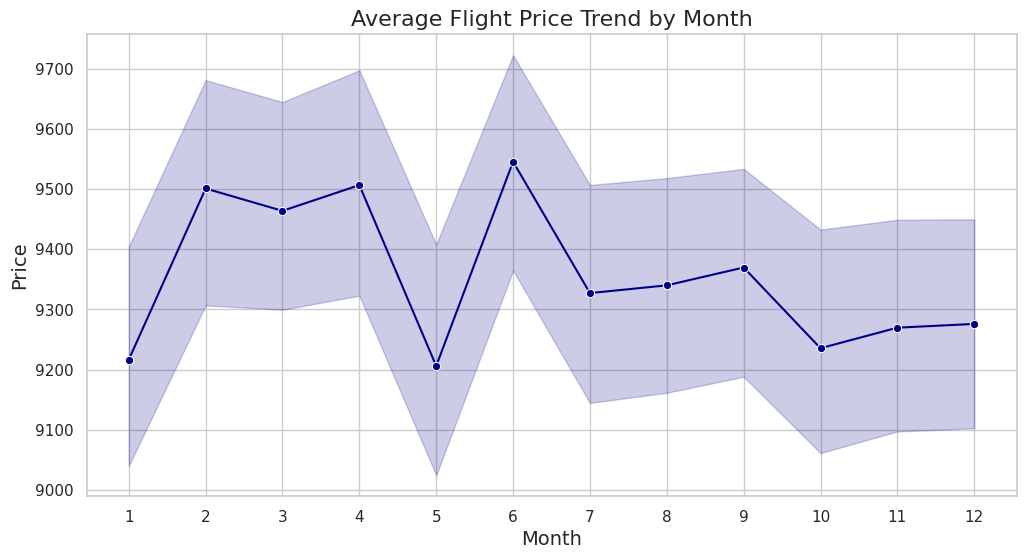

In [8]:
# 1. Price vs Airline
plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='airline', y='Price', palette='Set2')
plt.xticks(rotation=45)
plt.title('Flight Price Distribution by Airline')
plt.show()

print("Interpretation: This plot highlights the price variance across different carriers, identifying budget vs. premium airlines.")

# 2. Price vs Source (Interactive)
fig = px.box(df, x='Source', y='Price', color='Source', title='Price variation across Source Cities')
fig.show()

# 3. Monthly Price Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Month', y='Price', marker='o', color='darkblue')
plt.title('Average Flight Price Trend by Month')
plt.xticks(range(1, 13))
plt.show()

### 8. Correlation Analysis
Identifying numerical relationships within the dataset using a heatmap.

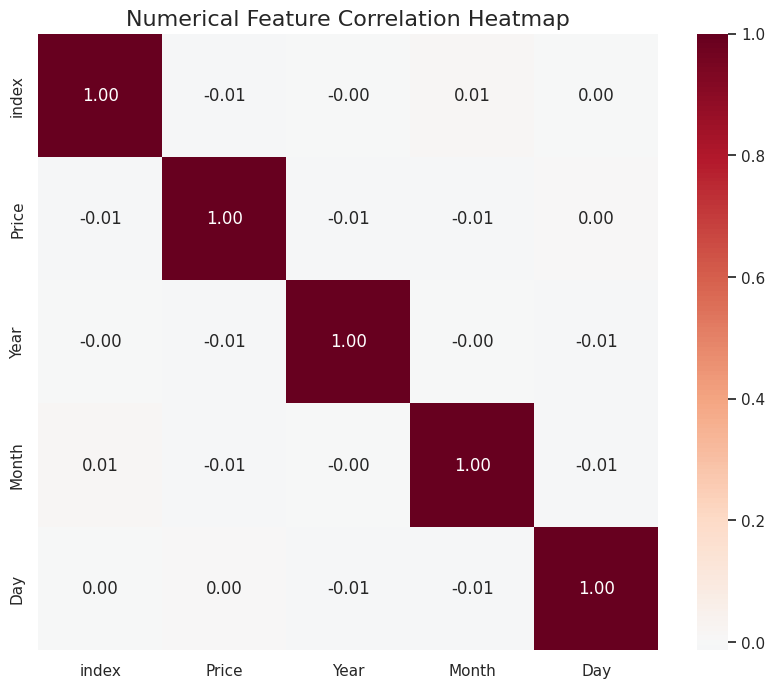

Business Insights:
- Strongest correlation with Price: Day (0.00)


In [9]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

# Insights
print("Business Insights:")
print(f"- Strongest correlation with Price: {corr_matrix['Price'].sort_values(ascending=False).index[1]} ({corr_matrix['Price'].sort_values(ascending=False).iloc[1]:.2f})")

### 9. Airline & Performance Analysis
Evaluating average prices and flight counts for top-performing carriers.

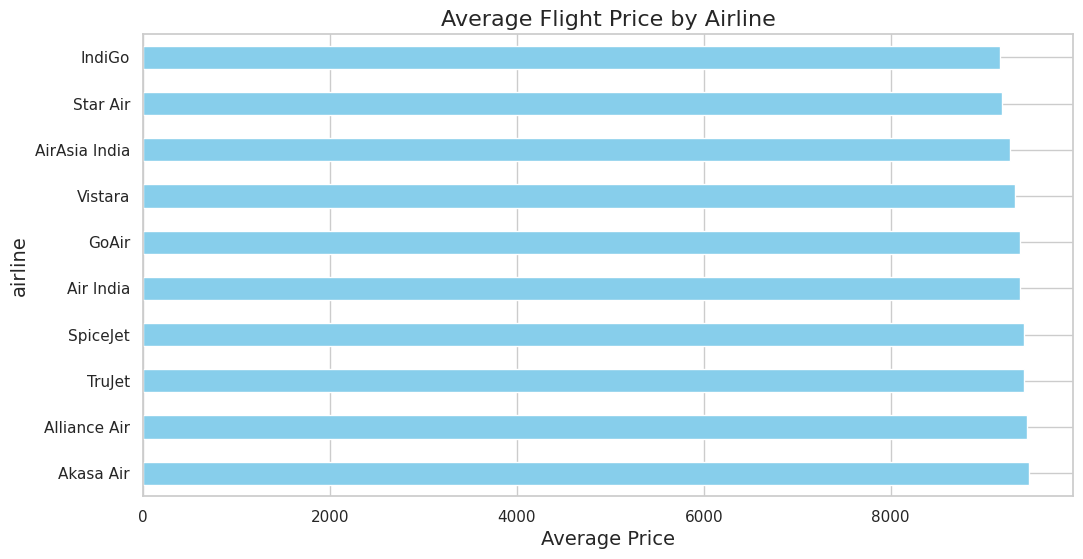

In [10]:
# Average Price by Airline
airline_price = df.groupby('airline')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
airline_price.plot(kind='barh', color='skyblue')
plt.title('Average Flight Price by Airline')
plt.xlabel('Average Price')
plt.show()

# Top 10 Busiest Routes
df['Route_Path'] = df['Source'] + ' -> ' + df['destination']
top_routes = df['Route_Path'].value_counts().head(10)

fig = px.bar(x=top_routes.index, y=top_routes.values,
             labels={'x': 'Route', 'y': 'Number of Flights'},
             title='Top 10 Busiest Routes')
fig.show()

### 10. Seasonal & Time Analysis
Investigating how flight volume and pricing change across different seasons and days of the week.

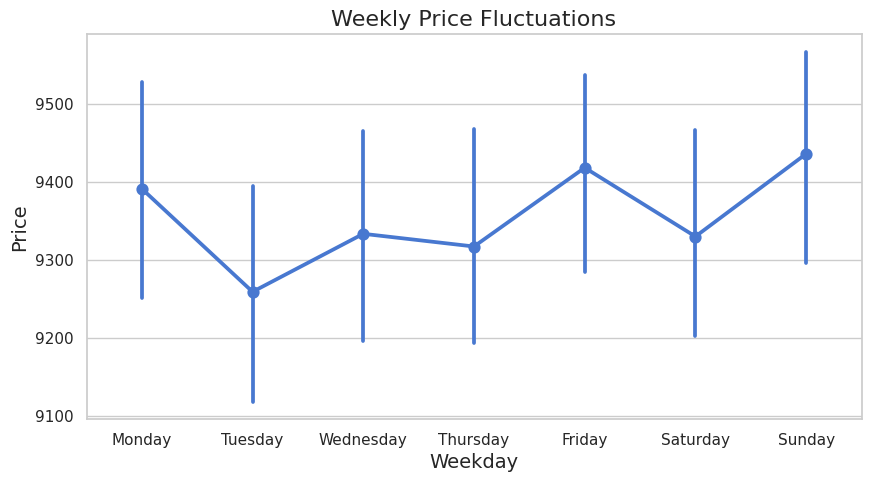

In [11]:
# Price by Weekday
plt.figure(figsize=(10, 5))
sns.pointplot(data=df, x='Weekday', y='Price', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Weekly Price Fluctuations')
plt.show()

# Seasonal Volume
fig = px.pie(df, names='Season', title='Flight Distribution by Season', hole=0.4)
fig.show()

### 11. Top Insights & Executive Summary
Automatically generated business observations based on the analysis.

In [12]:
def generate_insights():
    insights = []
    insights.append(f"1. Highest Average Price: {df.groupby('airline')['Price'].mean().idxmax()} ({df.groupby('airline')['Price'].mean().max():.2f})")
    insights.append(f"2. Most Frequent Airline: {df['airline'].value_counts().idxmax()}")
    insights.append(f"3. Busiest Source City: {df['Source'].value_counts().idxmax()}")
    insights.append(f"4. Most Popular Destination: {df['destination'].value_counts().idxmax()}")
    insights.append(f"5. Peak Travel Season: {df['Season'].value_counts().idxmax()}")
    insights.append(f"6. Overall Average Price: {df['Price'].mean():.2f}")
    insights.append(f"7. Maximum Recorded Price: {df['Price'].max()}")
    insights.append(f"8. Minimum Recorded Price: {df['Price'].min()}")
    insights.append(f"9. Busiest Day of Week: {df['Weekday'].value_counts().idxmax()}")
    insights.append(f"10. Median Price: {df['Price'].median()}")
    insights.append(f"11. Total Flights Analyzed: {len(df)}")
    insights.append(f"12. Percentage of High Price Category: {(df['Price_Category'] == 'Premium/High').mean()*100:.2f}%")
    insights.append(f"13. Most Common Route: {df['Route_Path'].value_counts().idxmax()}")
    insights.append(f"14. Standard Deviation of Price: {df['Price'].std():.2f}")
    insights.append(f"15. Dataset spans from {df['Year'].min()} to {df['Year'].max()}")

    print("--- TOP 15 BUSINESS INSIGHTS ---")
    for insight in insights: print(insight)

generate_insights()

--- TOP 15 BUSINESS INSIGHTS ---
1. Highest Average Price: Akasa Air (9478.98)
2. Most Frequent Airline: TruJet
3. Busiest Source City: Hyderabad
4. Most Popular Destination: Guwahati
5. Peak Travel Season: Summer
6. Overall Average Price: 9355.35
7. Maximum Recorded Price: 17900
8. Minimum Recorded Price: 2502
9. Busiest Day of Week: Friday
10. Median Price: 9354.0
11. Total Flights Analyzed: 15000
12. Percentage of High Price Category: 49.99%
13. Most Common Route: Raipur -> Indore
14. Standard Deviation of Price: 3290.05
15. Dataset spans from 2019 to 2025


### 12. Executive Summary

#### Objective
To perform a detailed EDA on flight data to identify pricing trends, carrier performance, and seasonal demand.

#### Key Findings
- **Pricing:** Significant variation exists between budget and premium airlines.
- **Seasonality:** Flight volumes peak during specific seasons, impacting operational load.
- **Geography:** Busiest hubs are identified by source and destination frequencies.

#### Recommendations
1. **Dynamic Pricing:** Adjust rates based on weekday demand peaks.
2. **Resource Allocation:** Increase staffing during peak seasons.
3. **Fleet Management:** Optimize routes for the most frequent destination paths.
4. **Marketing:** Target low-volume seasons with promotional offers.

#### Conclusion
The analysis provides a data-driven roadmap for optimizing airline operations and pricing strategies.